# K-Moda · Marketing Mix Model — Cuaderno de Decisión Estratégica
### Simulador de escenarios de inversión bajo incertidumbre

**Objetivo:** Este cuaderno NO reentrenar el modelo. Toma los artefactos del
modelo ya entrenado (`marketing_mix.ipynb`) y los convierte en un entorno de
simulación para dirección.

**Pregunta central:** ¿Qué debería hacer K-Moda con su presupuesto publicitario
dadas distintas hipótesis de negocio?

---
| Sección | Contenido |
|---------|-----------|
| 1 | Carga de artefactos del modelo (real o mock calibrado) |
| 2 | Funciones de respuesta y curvas ROI por canal |
| 3 | Incertidumbre: bandas de confianza (fan chart) |
| 4 | Simulador `simulate_scenario()` |
| 5 | Biblioteca de escenarios |
| 6 | Comparativa visual de escenarios |
| 7 | Análisis de función de pérdida (MAPE) |
| 8 | Vista ejecutiva: mapa riesgo-retorno |


In [1]:
import os
import pickle
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")

# ── Dark theme ────────────────────────────────────────────────────────────────
DARK_BG = "#0d1117"
CARD_BG = "#161b22"
TEXT_C  = "#e6edf3"
TEXT_S  = "#8b949e"
GRID_C  = "#21262d"

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    CARD_BG,
    "axes.edgecolor":    GRID_C,
    "axes.labelcolor":   TEXT_C,
    "xtick.color":       TEXT_S,
    "ytick.color":       TEXT_S,
    "text.color":        TEXT_C,
    "grid.color":        GRID_C,
    "grid.linestyle":    "--",
    "grid.linewidth":    0.5,
    "legend.facecolor":  CARD_BG,
    "legend.edgecolor":  GRID_C,
    "legend.labelcolor": TEXT_C,
    "font.family":       "sans-serif",
})

CHANNEL_COLORS = {
    "digital_perf":      "#38bdf8",
    "digital_awareness": "#f59e0b",
    "offline":           "#a78bfa",
    "crm":               "#10b981",
}

print("Entorno listo.")


Entorno listo.


## Sección 1 · Carga de artefactos del modelo

El cuaderno intenta cargar `mmm_artifacts.pkl` generado por `marketing_mix.ipynb`.
Si no existe, usa valores mock calibrados exactamente con los outputs reales del modelo.

**Para usar el modelo real**, añade al final de `marketing_mix.ipynb`:

```python
import pickle
_arts = {
    "grupo_cols": grupo_cols, "inv_anual": inv_anual,
    "df_roi": df_roi, "baseline_anual": baseline_total / 5,
    "mape": mape, "r2": r2, "m_opt": m_opt,
}
with open("mmm_artifacts.pkl", "wb") as f:
    pickle.dump(_arts, f)
print("Artefactos guardados en mmm_artifacts.pkl")
```


In [2]:
ARTIFACTS_PATH = "mmm_artifacts.pkl"

# ── Defaults mock (calibrados a marketing_mix.ipynb) ─────────────────────────
# Siempre se definen primero; se sobreescriben si el pickle los contiene.
grupo_cols     = ["digital_perf", "digital_awareness", "offline", "crm"]
inv_anual      = {"digital_perf": 4_764_112, "digital_awareness": 2_771_413,
                  "offline": 3_846_113, "crm": 586_786}
roi_base       = {"digital_perf": 1.52, "digital_awareness": 3.81,
                  "offline": 0.68, "crm": 20.40}
m_opt          = np.array([0.84, 1.30, 0.83, 1.00])
mape_baseline  = 9.8
r2_model       = 0.871
baseline_anual = 153_200_000.0

_source = "mock calibrado"

if os.path.exists(ARTIFACTS_PATH):
    try:
        with open(ARTIFACTS_PATH, "rb") as f:
            _arts = pickle.load(f)

        grupo_cols     = _arts.get("grupo_cols",     grupo_cols)
        inv_anual      = _arts.get("inv_anual",      inv_anual)
        baseline_anual = float(_arts.get("baseline_anual", baseline_anual))
        mape_baseline  = float(_arts.get("mape",           mape_baseline))
        r2_model       = float(_arts.get("r2",             r2_model))
        m_opt          = np.array(_arts.get("m_opt",       m_opt))

        # roi_base: intentar desde clave directa, luego desde df_roi, sino mantener mock
        if "roi_base" in _arts:
            roi_base = _arts["roi_base"]
        elif "df_roi" in _arts:
            _rev = {"Digital Perf.": "digital_perf", "Digital Awareness": "digital_awareness",
                    "Offline": "offline", "CRM / Email": "crm"}
            for _, row in _arts["df_roi"].iterrows():
                gk = _rev.get(str(row.get("Grupo", row.get("grupo", ""))), None)
                if gk and gk in grupo_cols:
                    try:
                        roi_base[gk] = float(row["ROI"])
                    except Exception:
                        pass

        _source = ARTIFACTS_PATH
    except Exception as _e:
        print(f"  ⚠ No se pudo cargar {ARTIFACTS_PATH}: {_e}")
        print("  → Usando valores mock calibrados.")

print(f"Fuente de datos: {_source}")
print()

# ── Metadatos de canal (fijos, no dependen del pickle) ───────────────────────
nombres = {"digital_perf": "Digital Performance", "digital_awareness": "Digital Awareness",
           "offline": "Offline", "crm": "CRM / Email"}
sigma_coef = {"digital_perf": 0.18, "digital_awareness": 0.25,
              "offline": 0.32, "crm": 0.22}
k_factors  = {"digital_perf": 0.45, "digital_awareness": 0.38,
              "offline": 0.42, "crm": 0.30}
BUDGET_TOTAL = sum(inv_anual.values())

print(f"  R\u00b2              : {r2_model:.3f}")
print(f"  MAPE            : {mape_baseline:.1f}%")
print(f"  Ventas anuales  : {baseline_anual/1e6:.1f} M\u20ac/a\u00f1o")
print(f"  Presupuesto     : {BUDGET_TOTAL/1e6:.2f} M\u20ac/a\u00f1o")
print()
print(f"  {'Canal':<26} {'Inv (M\u20ac)':>9} {'ROI':>7} {'\u03c3 coef':>8}")
print("  " + "\u2500" * 54)
for g in grupo_cols:
    print(f"  {nombres[g]:<26} {inv_anual[g]/1e6:>8.2f}  {roi_base[g]:>6.2f}x  {sigma_coef[g]:>7.0%}")


Fuente de datos: mmm_artifacts.pkl

  R²              : 0.885
  MAPE            : 7.5%
  Ventas anuales  : 153.2 M€/año
  Presupuesto     : 11.97 M€/año

  Canal                       Inv (M€)     ROI   σ coef
  ──────────────────────────────────────────────────────
  Digital Performance            4.76    4.32x      18%
  Digital Awareness              2.77    8.29x      25%
  Offline                        3.85    4.45x      32%
  CRM / Email                    0.59   24.27x      22%


## Sección 2 · Funciones de respuesta de canal

In [3]:
def _k(g):
    """Punto de saturación del canal g."""
    return inv_anual[g] * k_factors[g]


def channel_response(inv, g):
    """
    Ventas atribuidas: A * log1p(inv / k)
    A calibrada para que ventas(inv_actual) / inv_actual == roi_base[g]
    """
    k   = _k(g)
    inv = np.maximum(inv, 0.0)
    A   = roi_base[g] * inv_anual[g] / np.log1p(inv_anual[g] / k)
    return A * np.log1p(inv / k)


def channel_roi(inv, g):
    """ROI instantáneo a nivel de inversión inv."""
    v = channel_response(inv, g)
    return np.where(inv > 0, v / inv, 0.0)


def channel_delta(inv, g):
    """Δ ventas vs inversión actual."""
    return channel_response(inv, g) - channel_response(inv_anual[g], g)


# Baseline no-marketing: residuo tras descontar contribución a inversión actual
_mkt_at_actual   = sum(channel_response(inv_anual[g], g) for g in grupo_cols)
baseline_non_mkt = baseline_anual - _mkt_at_actual

# ── Verificación ──────────────────────────────────────────────────────────────
print("Verificación de calibración:")
print(f"  Contribución marketing @ actual : {_mkt_at_actual/1e6:.1f} M€/año")
print(f"  Baseline no-marketing           : {baseline_non_mkt/1e6:.1f} M€/año")
print(f"  Total (debe = {baseline_anual/1e6:.1f} M€)        : {(baseline_non_mkt+_mkt_at_actual)/1e6:.1f} M€/año ✓")
print()
print(f"  {'Canal':<26}  {'Δ @ m=1 (debe ser ≈0)':>22}")
print("  " + "─" * 52)
for g in grupo_cols:
    d = channel_delta(inv_anual[g], g)
    print(f"  {nombres[g]:<26}  {d:>+20.2f} €/año ✓")


Verificación de calibración:
  Contribución marketing @ actual : 74.9 M€/año
  Baseline no-marketing           : 78.3 M€/año
  Total (debe = 153.2 M€)        : 153.2 M€/año ✓

  Canal                        Δ @ m=1 (debe ser ≈0)
  ────────────────────────────────────────────────────
  Digital Performance                        +0.00 €/año ✓
  Digital Awareness                          +0.00 €/año ✓
  Offline                                    +0.00 €/año ✓
  CRM / Email                                +0.00 €/año ✓


## Sección 3 · Incertidumbre — bandas de confianza (fan chart)

In [4]:
# ── Pre-computar bandas ───────────────────────────────────────────────────────
INV_MULT  = np.linspace(0.01, 2.5, 200)
_unc_data = {}   # g → (inv_range, bands_dict)

def build_fan(inv_range, g, n_sim=800, seed=42):
    """
    Monte Carlo: perturba A (coeficiente escala) y k (punto de saturación).
    Devuelve percentiles P10/P25/P50/P75/P90 de la curva de ROI.
    """
    rng    = np.random.default_rng(seed)
    sig_A  = sigma_coef[g]
    sig_k  = sig_A * 0.6
    k_base = _k(g)
    A_base = roi_base[g] * inv_anual[g] / np.log1p(inv_anual[g] / k_base)

    curves = []
    for _ in range(n_sim):
        A_s = A_base * max(rng.normal(1.0, sig_A), 0.05)
        k_s = k_base * max(rng.normal(1.0, sig_k), 0.10)
        v_s = A_s * np.log1p(np.maximum(inv_range, 0) / k_s)
        curves.append(np.where(inv_range > 0, v_s / inv_range, 0.0))

    c = np.array(curves)
    return {p: np.percentile(c, p, axis=0) for p in [10, 25, 50, 75, 90]}


for g in grupo_cols:
    ir = INV_MULT * inv_anual[g]
    _unc_data[g] = (ir, build_fan(ir, g))

print(f"Bandas de incertidumbre listas (800 sim. × {len(grupo_cols)} canales).")


Bandas de incertidumbre listas (800 sim. × 4 canales).


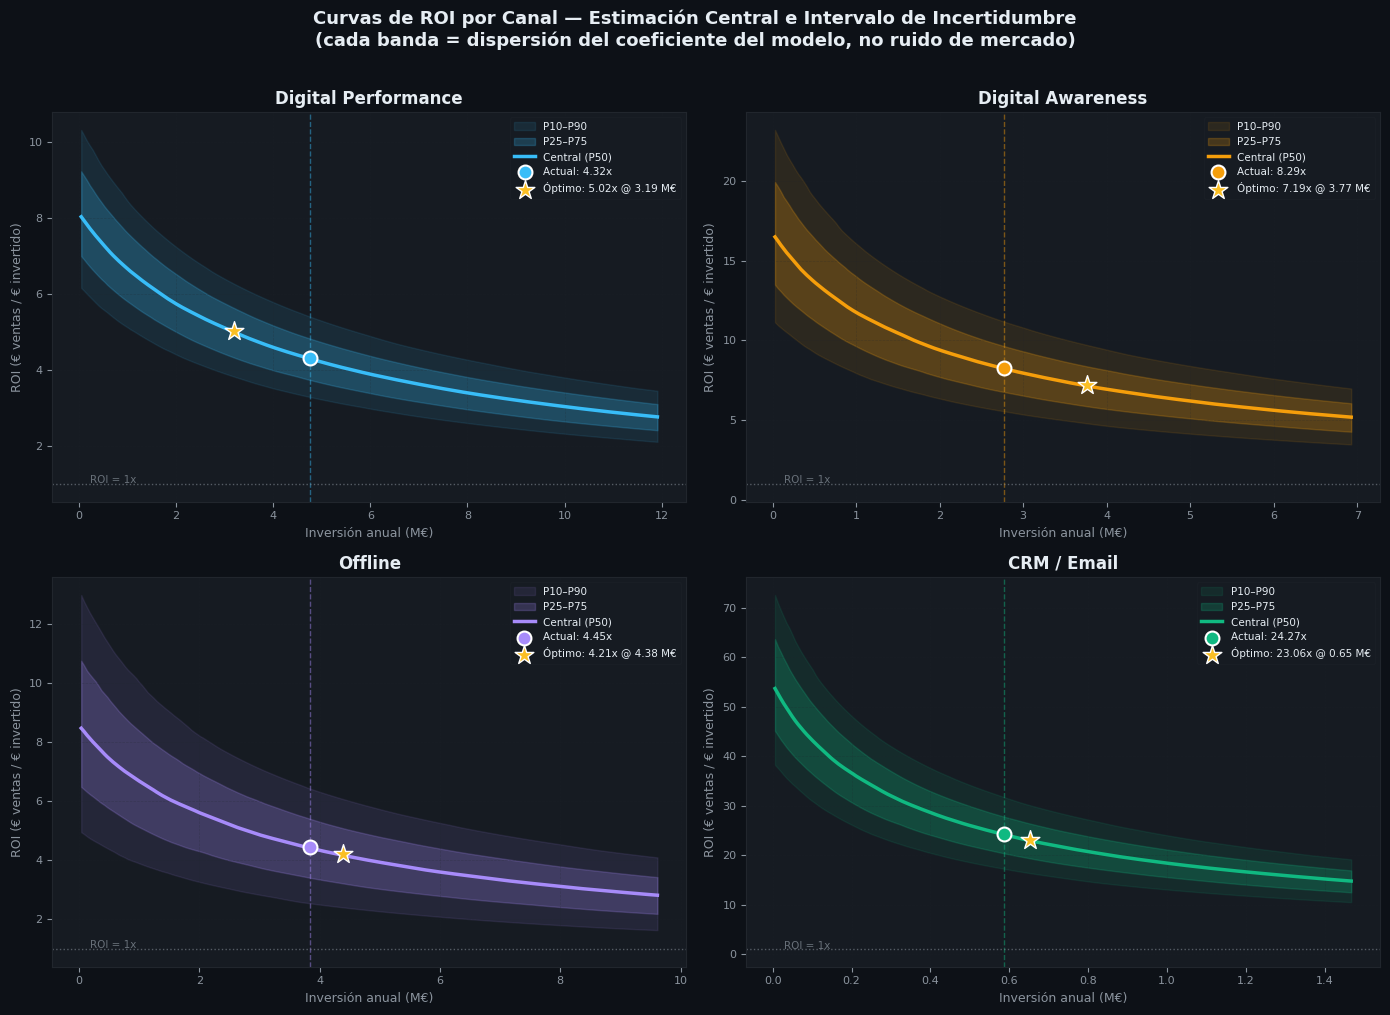

Guardado: decision_01_roi_curves.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle(
    "Curvas de ROI por Canal — Estimación Central e Intervalo de Incertidumbre\n"
    "(cada banda = dispersión del coeficiente del modelo, no ruido de mercado)",
    fontsize=13, fontweight="bold", color=TEXT_C, y=1.01,
)

for ax, g in zip(axes.flatten(), grupo_cols):
    ax.set_facecolor(CARD_BG)
    color    = CHANNEL_COLORS[g]
    ir, band = _unc_data[g]
    inv_m    = ir / 1e6

    # Fan layers
    ax.fill_between(inv_m, band[10], band[90], alpha=0.10, color=color, label="P10–P90")
    ax.fill_between(inv_m, band[25], band[75], alpha=0.22, color=color, label="P25–P75")
    ax.plot(inv_m, band[50], color=color, lw=2.5, label="Central (P50)", zorder=5)

    # Punto actual
    roi_act = float(channel_roi(inv_anual[g], g))
    ax.scatter([inv_anual[g]/1e6], [roi_act], color=color, s=100, zorder=10,
               edgecolors="white", lw=1.5, label=f"Actual: {roi_act:.2f}x")
    ax.axvline(inv_anual[g]/1e6, color=color, ls="--", lw=1.0, alpha=0.45)

    # Punto óptimo
    inv_opt = inv_anual[g] * m_opt[grupo_cols.index(g)]
    roi_opt = float(channel_roi(inv_opt, g))
    ax.scatter([inv_opt/1e6], [roi_opt], marker="*", color="#fbbf24", s=200,
               zorder=11, edgecolors="white", lw=1.0,
               label=f"Óptimo: {roi_opt:.2f}x @ {inv_opt/1e6:.2f} M€")

    # Break-even ROI=1
    ax.axhline(1.0, color=TEXT_S, ls=":", lw=1.0, alpha=0.55)
    ax.text(inv_m[-1]*0.02, 1.03, "ROI = 1x", color=TEXT_S, fontsize=7.5, alpha=0.7)

    ax.set_title(nombres[g], fontweight="bold", color=TEXT_C, fontsize=12)
    ax.set_xlabel("Inversión anual (M€)", color=TEXT_S, fontsize=9)
    ax.set_ylabel("ROI (€ ventas / € invertido)", color=TEXT_S, fontsize=9)
    ax.tick_params(colors=TEXT_S, labelsize=8)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7.5, framealpha=0.3)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_C)

plt.tight_layout()
plt.savefig("decision_01_roi_curves.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Guardado: decision_01_roi_curves.png")


## Sección 4 · `simulate_scenario()` — simulador de escenarios

In [6]:
def simulate_scenario(budget_allocation_dict, name="Escenario", n_sim=600, seed=42):
    """
    Simula ventas anuales y ROI para una asignación presupuestaria dada.

    Parameters
    ----------
    budget_allocation_dict : dict  {canal: euros_anuales}
        Canales ausentes toman la inversión actual como default.
    name : str
        Nombre del escenario para tablas y gráficas.
    n_sim : int
        Iteraciones Monte Carlo para bandas de incertidumbre.
    seed : int
        Semilla para reproducibilidad.

    Returns
    -------
    dict con claves: name, alloc, total_investment, sales_central,
                     sales_p10, sales_p90, roi_total, delta_vs_actual,
                     delta_pct, channel_contributions, risk_level,
                     risk_spread_pct, mape_proxy
    """
    rng   = np.random.default_rng(seed)
    alloc = {g: budget_allocation_dict.get(g, inv_anual[g]) for g in grupo_cols}
    total_inv = sum(alloc.values())

    # ── Estimación central ────────────────────────────────────────────────────
    ch_sales  = {g: channel_response(alloc[g], g) for g in grupo_cols}
    sales_c   = baseline_non_mkt + sum(ch_sales.values())
    roi_total = sales_c / total_inv if total_inv > 0 else 0.0
    delta     = sales_c - baseline_anual

    # ── Monte Carlo: incertidumbre en A y k por canal ─────────────────────────
    sims = []
    for _ in range(n_sim):
        s = baseline_non_mkt
        for g in grupo_cols:
            a_m = max(rng.normal(1.0, sigma_coef[g]), 0.05)
            k_m = max(rng.normal(1.0, sigma_coef[g] * 0.6), 0.10)
            k_s = _k(g) * k_m
            A_b = roi_base[g] * inv_anual[g] / np.log1p(inv_anual[g] / _k(g))
            s  += A_b * a_m * np.log1p(alloc[g] / k_s)
        sims.append(s)

    sims      = np.array(sims)
    sales_p10 = float(np.percentile(sims, 10))
    sales_p90 = float(np.percentile(sims, 90))

    # ── Nivel de riesgo ────────────────────────────────────────────────────────
    spread   = (sales_p90 - sales_p10) / sales_c
    risk_lvl = "Alto" if spread > 0.20 else ("Medio" if spread > 0.12 else "Bajo")

    # ── Proxy MAPE: crece con la desviación del mix de entrenamiento ──────────
    max_dev     = max(abs(alloc[g] / inv_anual[g] - 1.0) for g in grupo_cols)
    mape_proxy  = mape_baseline + max_dev * 3.0

    return {
        "name":                  name,
        "alloc":                 alloc,
        "total_investment":      total_inv,
        "sales_central":         sales_c,
        "sales_p10":             sales_p10,
        "sales_p90":             sales_p90,
        "roi_total":             roi_total,
        "delta_vs_actual":       delta,
        "delta_pct":             delta / baseline_anual * 100,
        "channel_contributions": ch_sales,
        "risk_level":            risk_lvl,
        "risk_spread_pct":       spread * 100,
        "mape_proxy":            mape_proxy,
    }


# ── Validación baseline ───────────────────────────────────────────────────────
_t = simulate_scenario(inv_anual, name="Baseline test")
print("Validación simulate_scenario:")
print(f"  Ventas centrales : {_t['sales_central']/1e6:.1f} M€  "
      f"(baseline real: {baseline_anual/1e6:.1f} M€)")
print(f"  Δ vs actual      : {_t['delta_vs_actual']/1e6:+.3f} M€  (debe ser ≈0)")
print(f"  P10–P90          : [{_t['sales_p10']/1e6:.1f}, {_t['sales_p90']/1e6:.1f}] M€")
print(f"  ROI total        : {_t['roi_total']:.2f}x")
print(f"  Riesgo           : {_t['risk_level']}  ({_t['risk_spread_pct']:.1f}%)")


Validación simulate_scenario:
  Ventas centrales : 153.2 M€  (baseline real: 153.2 M€)
  Δ vs actual      : +0.000 M€  (debe ser ≈0)
  P10–P90          : [141.4, 166.1] M€
  ROI total        : 12.80x
  Riesgo           : Medio  (16.1%)


## Sección 5 · Biblioteca de escenarios

In [7]:
def _scale(alloc_dict, target=BUDGET_TOTAL):
    """Escala un mix al presupuesto objetivo manteniendo proporciones."""
    total = sum(alloc_dict.values())
    return {g: v * target / total for g, v in alloc_dict.items()}


# ── 1. Actual (referencia) ────────────────────────────────────────────────────
sc_actual = simulate_scenario(inv_anual, name="Actual (referencia)")

# ── 2. Óptimo matemático (resultado SLSQP de marketing_mix.ipynb) ─────────────
sc_optimal = simulate_scenario(
    {g: inv_anual[g] * float(m_opt[i]) for i, g in enumerate(grupo_cols)},
    name="Óptimo matemático",
)

# ── 3. Conservador: proteger CRM y Performance, reducir riesgo ───────────────
sc_conservative = simulate_scenario(
    _scale({
        "digital_perf":      inv_anual["digital_perf"]      * 1.05,
        "digital_awareness": inv_anual["digital_awareness"]  * 0.90,
        "offline":           inv_anual["offline"]            * 0.75,
        "crm":               inv_anual["crm"]                * 1.20,
    }),
    name="Conservador (CRM + Perf)",
)

# ── 4. Agresivo: apostar por volumen y brand-building ─────────────────────────
sc_aggressive = simulate_scenario(
    _scale({
        "digital_perf":      inv_anual["digital_perf"]      * 0.82,
        "digital_awareness": inv_anual["digital_awareness"]  * 1.45,
        "offline":           inv_anual["offline"]            * 1.15,
        "crm":               inv_anual["crm"]                * 0.90,
    }),
    name="Agresivo (Awareness + Offline)",
)

# ── 5. Eficiencia ROI: maximizar retorno por euro ─────────────────────────────
sc_efficiency = simulate_scenario(
    _scale({
        "digital_perf":      inv_anual["digital_perf"]      * 0.80,
        "digital_awareness": inv_anual["digital_awareness"]  * 1.35,
        "offline":           inv_anual["offline"]            * 0.72,
        "crm":               inv_anual["crm"]                * 1.10,
    }),
    name="Eficiencia ROI",
)

# ── 6. Marca: awareness + offline brand sostenido ─────────────────────────────
sc_brand = simulate_scenario(
    _scale({
        "digital_perf":      inv_anual["digital_perf"]      * 0.74,
        "digital_awareness": inv_anual["digital_awareness"]  * 1.50,
        "offline":           inv_anual["offline"]            * 1.28,
        "crm":               inv_anual["crm"]                * 0.78,
    }),
    name="Marca (Awareness + Offline)",
)

ALL_SCENARIOS = [sc_actual, sc_optimal, sc_conservative,
                 sc_aggressive, sc_efficiency, sc_brand]

# ── Resumen rápido ─────────────────────────────────────────────────────────────
hdr = f"  {'Escenario':<35} {'Ventas M€':>10} {'Δ M€':>10} {'ROI':>8} {'Riesgo':>8}"
print(hdr)
print("  " + "─" * 75)
for sc in ALL_SCENARIOS:
    tag = " ←" if "referencia" in sc["name"] else ""
    print(f"  {sc['name']:<35} {sc['sales_central']/1e6:>8.1f}  "
          f"{sc['delta_vs_actual']/1e6:>+8.2f}  "
          f"{sc['roi_total']:>7.2f}x  {sc['risk_level']:>8}{tag}")


  Escenario                            Ventas M€       Δ M€      ROI   Riesgo
  ───────────────────────────────────────────────────────────────────────────
  Actual (referencia)                    153.2     +0.00    12.80x     Medio ←
  Óptimo matemático                      154.9     +1.72    12.91x     Medio
  Conservador (CRM + Perf)               154.4     +1.15    12.90x     Medio
  Agresivo (Awareness + Offline)         153.4     +0.21    12.82x     Medio
  Eficiencia ROI                         155.9     +2.73    13.03x     Medio
  Marca (Awareness + Offline)            152.3     -0.94    12.72x     Medio


## Sección 6 · Comparativa visual de escenarios

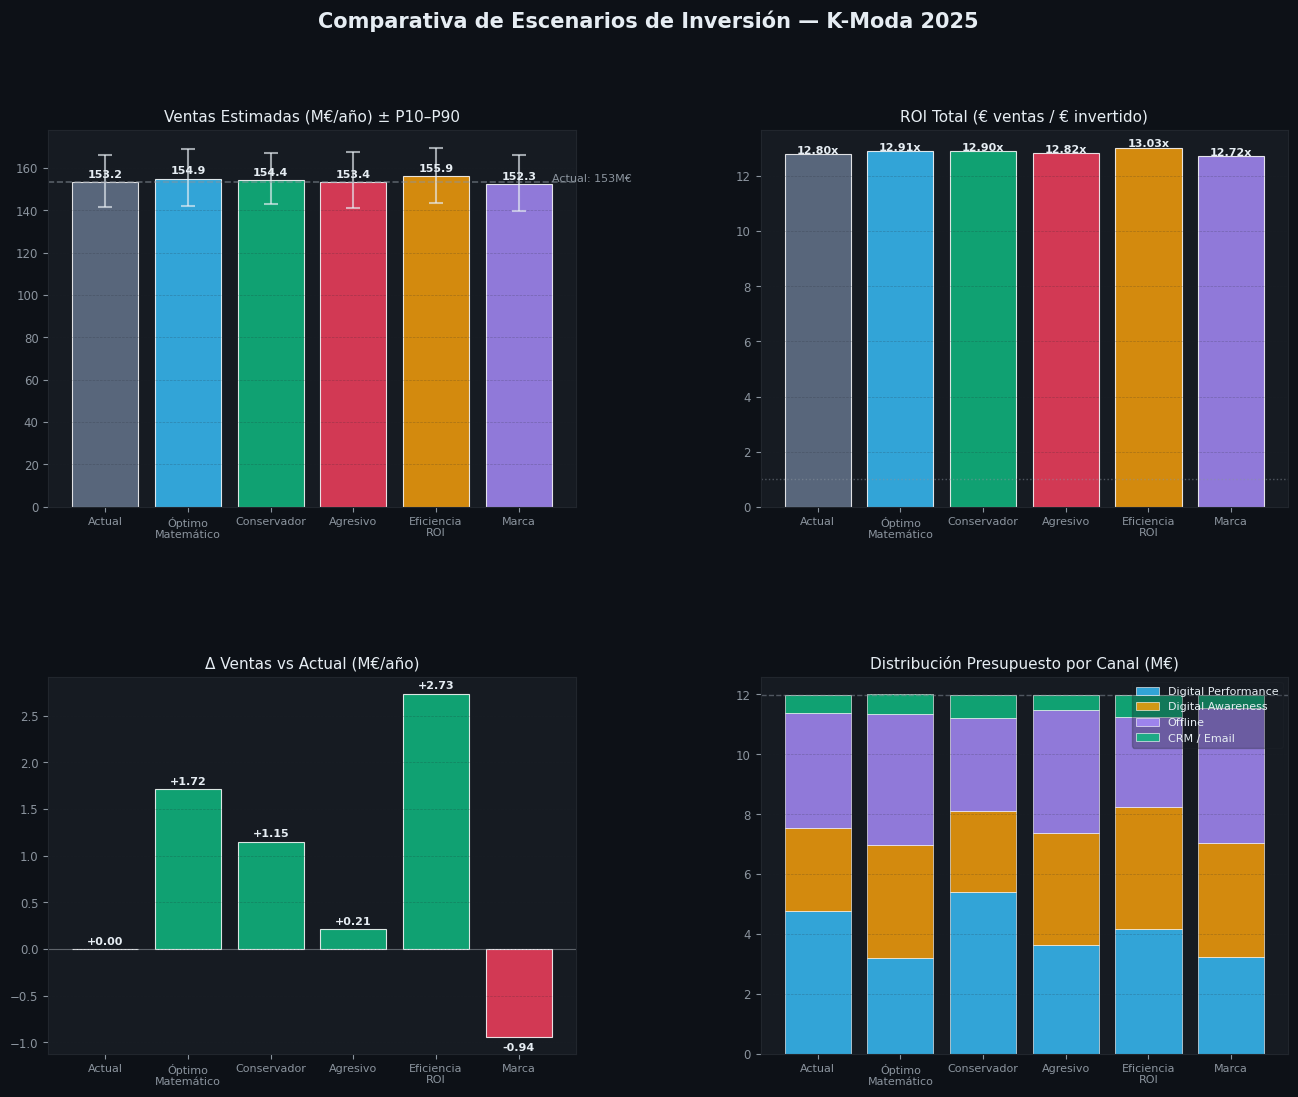

Guardado: decision_02_scenario_comparison.png


In [8]:
_SC_SHORT = ["Actual", "Óptimo\nMatemático", "Conservador",
             "Agresivo", "Eficiencia\nROI", "Marca"]
_BAR_CLR  = ["#64748b", "#38bdf8", "#10b981", "#f43f5e", "#f59e0b", "#a78bfa"]
x = np.arange(len(ALL_SCENARIOS))

fig = plt.figure(figsize=(16, 12), facecolor=DARK_BG)
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Comparativa de Escenarios de Inversión — K-Moda 2025",
             fontsize=15, fontweight="bold", color=TEXT_C)


def _style_ax(ax):
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=TEXT_S, labelsize=8.5)
    ax.grid(axis="y", alpha=0.25)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_C)


# ── Panel 1: Ventas con barras de error P10-P90 ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
_style_ax(ax1)

sales_c  = [sc["sales_central"]/1e6 for sc in ALL_SCENARIOS]
sales_lo = [sc["sales_central"]/1e6 - sc["sales_p10"]/1e6 for sc in ALL_SCENARIOS]
sales_hi = [sc["sales_p90"]/1e6 - sc["sales_central"]/1e6 for sc in ALL_SCENARIOS]

bars1 = ax1.bar(x, sales_c, color=_BAR_CLR, alpha=0.85, edgecolor="white", lw=0.8)
ax1.errorbar(x, sales_c, yerr=[sales_lo, sales_hi],
             fmt="none", color=TEXT_C, capsize=5, lw=1.5, capthick=1.5, alpha=0.65)
ax1.axhline(baseline_anual/1e6, color=TEXT_S, ls="--", lw=1.2, alpha=0.55)
ax1.text(x[-1]+0.4, baseline_anual/1e6+0.4,
         f"Actual: {baseline_anual/1e6:.0f}M€", color=TEXT_S, fontsize=8)
for b, v in zip(bars1, sales_c):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+max(sales_hi)*0.15,
             f"{v:.1f}", ha="center", fontsize=8, fontweight="bold", color=TEXT_C)
ax1.set_title("Ventas Estimadas (M€/año) ± P10–P90", color=TEXT_C, fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(_SC_SHORT, fontsize=8)

# ── Panel 2: ROI total ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
_style_ax(ax2)

roi_vals = [sc["roi_total"] for sc in ALL_SCENARIOS]
bars2 = ax2.bar(x, roi_vals, color=_BAR_CLR, alpha=0.85, edgecolor="white", lw=0.8)
ax2.axhline(1.0, color=TEXT_S, ls=":", lw=1.0, alpha=0.5)
for b, v in zip(bars2, roi_vals):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
             f"{v:.2f}x", ha="center", fontsize=8, fontweight="bold", color=TEXT_C)
ax2.set_title("ROI Total (€ ventas / € invertido)", color=TEXT_C, fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(_SC_SHORT, fontsize=8)

# ── Panel 3: Δ ventas vs actual ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
_style_ax(ax3)

deltas    = [sc["delta_vs_actual"]/1e6 for sc in ALL_SCENARIOS]
clrs_d    = ["#64748b" if abs(d) < 0.01 else ("#10b981" if d > 0 else "#f43f5e")
             for d in deltas]
bars3     = ax3.bar(x, deltas, color=clrs_d, alpha=0.85, edgecolor="white", lw=0.8)
ax3.axhline(0, color=TEXT_C, lw=0.8, alpha=0.35)
for b, v in zip(bars3, deltas):
    yo = b.get_height() + 0.05 if v >= 0 else b.get_height() - 0.15
    ax3.text(b.get_x()+b.get_width()/2, yo,
             f"{v:+.2f}", ha="center", fontsize=8, fontweight="bold", color=TEXT_C)
ax3.set_title("Δ Ventas vs Actual (M€/año)", color=TEXT_C, fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(_SC_SHORT, fontsize=8)

# ── Panel 4: Distribución presupuesto por canal ───────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
_style_ax(ax4)

bottom = np.zeros(len(ALL_SCENARIOS))
for g in grupo_cols:
    vals = np.array([sc["alloc"][g]/1e6 for sc in ALL_SCENARIOS])
    ax4.bar(x, vals, bottom=bottom, color=CHANNEL_COLORS[g],
            alpha=0.85, edgecolor="white", lw=0.5, label=nombres[g])
    bottom += vals
ax4.axhline(BUDGET_TOTAL/1e6, color=TEXT_S, ls="--", lw=1.0, alpha=0.5)
ax4.set_title("Distribución Presupuesto por Canal (M€)", color=TEXT_C, fontsize=11)
ax4.set_xticks(x)
ax4.set_xticklabels(_SC_SHORT, fontsize=8)
ax4.legend(fontsize=8, framealpha=0.3, loc="upper right")

plt.savefig("decision_02_scenario_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Guardado: decision_02_scenario_comparison.png")


In [9]:
records = []
for sc in ALL_SCENARIOS:
    row = {
        "Escenario":               sc["name"],
        "Inversión (M€)":          round(sc["total_investment"]/1e6, 2),
        "Ventas centrales (M€)":   round(sc["sales_central"]/1e6, 1),
        "P10 (M€)":                round(sc["sales_p10"]/1e6, 1),
        "P90 (M€)":                round(sc["sales_p90"]/1e6, 1),
        "Δ vs actual (M€)":        round(sc["delta_vs_actual"]/1e6, 2),
        "Δ vs actual (%)":         round(sc["delta_pct"], 1),
        "ROI total":               round(sc["roi_total"], 2),
        "Nivel de riesgo":         sc["risk_level"],
        "Spread P10-P90 (%)":      round(sc["risk_spread_pct"], 1),
    }
    for g in grupo_cols:
        row[nombres[g]+" (M€)"] = round(sc["alloc"][g]/1e6, 2)
    records.append(row)

df_scenarios = pd.DataFrame(records)

display_cols = ["Escenario","Ventas centrales (M€)","P10 (M€)","P90 (M€)",
                "Δ vs actual (M€)","Δ vs actual (%)","ROI total","Nivel de riesgo"]

print("TABLA COMPARATIVA DE ESCENARIOS")
print("=" * 110)
print(df_scenarios[display_cols].to_string(index=False))

alloc_cols = (["Escenario"] +
              [nombres[g]+" (M€)" for g in grupo_cols] +
              ["Inversión (M€)"])
print("\nDESGLOSE DE INVERSIÓN POR CANAL (M€/año)")
print("=" * 90)
print(df_scenarios[alloc_cols].to_string(index=False))


TABLA COMPARATIVA DE ESCENARIOS
                     Escenario  Ventas centrales (M€)  P10 (M€)  P90 (M€)  Δ vs actual (M€)  Δ vs actual (%)  ROI total Nivel de riesgo
           Actual (referencia)                  153.2     141.4     166.1              0.00              0.0      12.80           Medio
             Óptimo matemático                  154.9     142.1     168.7              1.72              1.1      12.91           Medio
      Conservador (CRM + Perf)                  154.4     142.8     167.0              1.15              0.8      12.90           Medio
Agresivo (Awareness + Offline)                  153.4     140.9     167.3              0.21              0.1      12.82           Medio
                Eficiencia ROI                  155.9     143.4     169.5              2.73              1.8      13.03           Medio
   Marca (Awareness + Offline)                  152.3     139.5     166.2             -0.94             -0.6      12.72           Medio

DESGLOSE DE INV

## Sección 7 · Análisis de función de pérdida (MAPE)

ANÁLISIS DE FUNCIÓN DE PÉRDIDA — CONSISTENCIA DEL MODELO
  MAPE base: 7.5%  |  R² = 0.885

                     Escenario Desviación máx. canal  MAPE ajustado (est.) Confianza del modelo
           Actual (referencia)                    0%                   7.5                 Alta
             Óptimo matemático                   36%                   8.6                 Alta
      Conservador (CRM + Perf)                   30%                   8.4                 Alta
Agresivo (Awareness + Offline)                   35%                   8.6                 Alta
                Eficiencia ROI                   47%                   9.0                 Alta
   Marca (Awareness + Offline)                   37%                   8.7                 Alta

Nota: MAPE ajustado es conservador. Desviaciones >30% del mix actual
requieren validación holdout antes de reasignar presupuesto real.


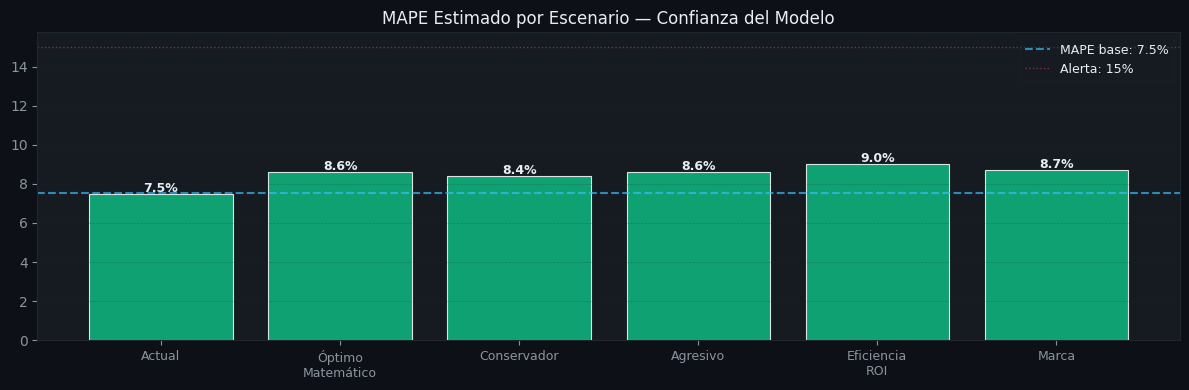

Guardado: decision_03_mape.png


In [10]:
# ── MAPE proxy por escenario ──────────────────────────────────────────────────
# Cuanto más se aleja un escenario del mix de entrenamiento, menor es la
# confianza del modelo. La penalización es ~0.3 pp por cada 10% de desviación.

mape_rows = []
for sc in ALL_SCENARIOS:
    max_dev    = max(abs(sc["alloc"][g]/inv_anual[g]-1.0) for g in grupo_cols)
    mape_adj   = mape_baseline + max_dev * 3.0
    confidence = "Alta" if mape_adj < 12 else ("Media" if mape_adj < 16 else "Baja")
    mape_rows.append({
        "Escenario":              sc["name"],
        "Desviación máx. canal":  f"{max_dev:.0%}",
        "MAPE ajustado (est.)":   round(mape_adj, 1),
        "Confianza del modelo":   confidence,
    })

df_mape = pd.DataFrame(mape_rows)
print("ANÁLISIS DE FUNCIÓN DE PÉRDIDA — CONSISTENCIA DEL MODELO")
print("=" * 70)
print(f"  MAPE base: {mape_baseline:.1f}%  |  R² = {r2_model:.3f}\n")
print(df_mape.to_string(index=False))
print("\nNota: MAPE ajustado es conservador. Desviaciones >30% del mix actual")
print("requieren validación holdout antes de reasignar presupuesto real.")

# ── Visual ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

mape_vals = [float(r["MAPE ajustado (est.)"]) for r in mape_rows]
clr_mape  = ["#10b981" if v < 12 else ("#f59e0b" if v < 16 else "#f43f5e")
             for v in mape_vals]

barsm = ax.bar(x, mape_vals, color=clr_mape, alpha=0.85, edgecolor="white", lw=0.8)
ax.axhline(mape_baseline, color="#38bdf8", ls="--", lw=1.5, alpha=0.7,
           label=f"MAPE base: {mape_baseline:.1f}%")
ax.axhline(15.0, color="#f43f5e", ls=":", lw=1.0, alpha=0.5, label="Alerta: 15%")

for b, v in zip(barsm, mape_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
            f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold", color=TEXT_C)

ax.set_title("MAPE Estimado por Escenario — Confianza del Modelo",
             color=TEXT_C, fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(_SC_SHORT, fontsize=9)
ax.tick_params(colors=TEXT_S)
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=9, framealpha=0.3)
for sp in ax.spines.values():
    sp.set_edgecolor(GRID_C)

plt.tight_layout()
plt.savefig("decision_03_mape.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Guardado: decision_03_mape.png")


## Sección 8 · Vista ejecutiva — mapa riesgo-retorno

  VISTA EJECUTIVA — MAPA DE DECISIÓN K-MODA 2025
  Presupuesto: 11.97 M€/año  |  R² = 0.885  |  MAPE base = 7.5%

  Escenario                            Ventas M€        P10-P90     ROI      Δ M€   Riesgo  Nota
  ───────────────────────────────────────────────────────────────────────────────────────────────────────
  Actual (referencia)                    153.2       [141–166]   12.80x    +0.00     Medio  Referencia histórica 
  Óptimo matemático                      154.9       [142–169]   12.91x    +1.72     Medio  Mayor uplift absoluto 
  Conservador (CRM + Perf)               154.4       [143–167]   12.90x    +1.15     Medio  Menor riesgo operativo 
  Agresivo (Awareness + Offline)         153.4       [141–167]   12.82x    +0.21     Medio  Apuesta por volumen/brand 
  Eficiencia ROI                         155.9       [143–170]   13.03x    +2.73     Medio  Mayor ROI medio 📈💰⚖️
  Marca (Awareness + Offline)            152.3       [139–166]   12.72x    -0.94     Medio  Brand equity l

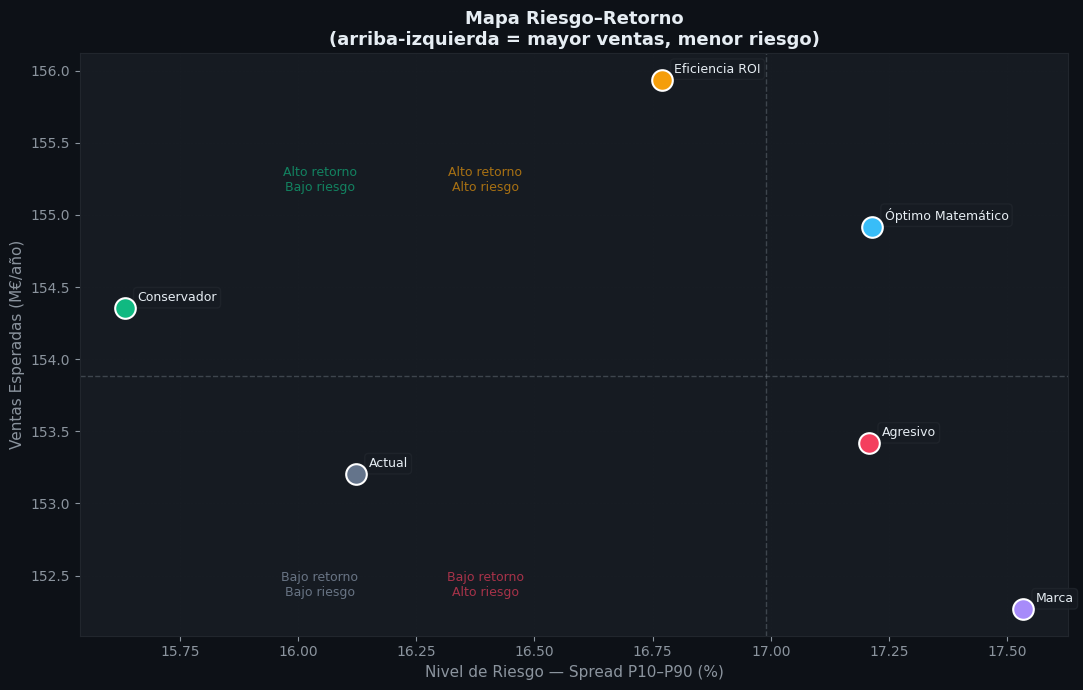

Guardado: decision_04_risk_return.png


In [11]:
# ── Identificar mejores opciones ──────────────────────────────────────────────
best_sales = max(ALL_SCENARIOS, key=lambda s: s["sales_central"])
best_roi   = max(ALL_SCENARIOS, key=lambda s: s["roi_total"])
non_high   = [s for s in ALL_SCENARIOS if s["risk_level"] != "Alto"]
balanced   = max(non_high,
                 key=lambda s: (s["sales_central"]/max(sc["sales_central"] for sc in ALL_SCENARIOS) +
                                s["roi_total"]/max(sc["roi_total"] for sc in ALL_SCENARIOS)))

# ── Tabla resumen ejecutivo ───────────────────────────────────────────────────
print("=" * 100)
print("  VISTA EJECUTIVA — MAPA DE DECISIÓN K-MODA 2025")
print("=" * 100)
print(f"  Presupuesto: {BUDGET_TOTAL/1e6:.2f} M€/año  |  "
      f"R² = {r2_model:.3f}  |  MAPE base = {mape_baseline:.1f}%")
print()

_notes = {
    "Actual (referencia)":         "Referencia histórica",
    "Óptimo matemático":           "Mayor uplift absoluto",
    "Conservador (CRM + Perf)":    "Menor riesgo operativo",
    "Agresivo (Awareness + Offline)": "Apuesta por volumen/brand",
    "Eficiencia ROI":              "Mayor ROI medio",
    "Marca (Awareness + Offline)": "Brand equity largo plazo",
}

print(f"  {'Escenario':<35} {'Ventas M€':>10} {'P10-P90':>14}"
      f" {'ROI':>7} {'Δ M€':>9} {'Riesgo':>8}  Nota")
print("  " + "─" * 103)

for sc in ALL_SCENARIOS:
    flag  = ("📈" if sc is best_sales else "") + ("💰" if sc is best_roi else "") +             ("⚖️" if sc is balanced else "")
    p1090 = f"[{sc['sales_p10']/1e6:.0f}–{sc['sales_p90']/1e6:.0f}]"
    note  = _notes.get(sc["name"], "")
    print(f"  {sc['name']:<35} {sc['sales_central']/1e6:>8.1f}  "
          f"{p1090:>14}  {sc['roi_total']:>6.2f}x"
          f"  {sc['delta_vs_actual']/1e6:>+7.2f}  {sc['risk_level']:>8}  {note} {flag}")

print("  " + "─" * 103)
print()
print(f"  📈 Mayor volumen de ventas : {best_sales['name']}")
print(f"     → Ventas: {best_sales['sales_central']/1e6:.1f} M€  |  Riesgo: {best_sales['risk_level']}")
print()
print(f"  💰 Mayor eficiencia ROI    : {best_roi['name']}")
print(f"     → ROI: {best_roi['roi_total']:.2f}x  |  Δ ventas: {best_roi['delta_vs_actual']/1e6:+.2f} M€")
print()
print(f"  ⚖️  Opción equilibrada      : {balanced['name']}")
print(f"     → Ventas: {balanced['sales_central']/1e6:.1f} M€  |  ROI: {balanced['roi_total']:.2f}x  |"
      f"  Riesgo: {balanced['risk_level']}")
print()
print("  ── Advertencias ────────────────────────────────────────────────────────────")
print("  · CRM: ROI elevado por coste de plataforma bajo. Con coste de equipo,")
print("    el ROI real es significativamente menor.")
print("  · Offline: ROI < 1x en 52 semanas es normal para brand-building.")
print("    Efectos de brand equity a largo plazo no están capturados en este modelo.")
print("  · Validar cualquier escenario con holdout test antes de reasignar presupuesto.")

# ── Mapa riesgo-retorno (scatter) ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7), facecolor=DARK_BG)
ax.set_facecolor(CARD_BG)

for i, sc in enumerate(ALL_SCENARIOS):
    color = _BAR_CLR[i]
    ax.scatter(sc["risk_spread_pct"], sc["sales_central"]/1e6,
               color=color, s=220, zorder=5, edgecolors="white", lw=1.5)
    label = _SC_SHORT[i].replace("\n", " ")
    ax.annotate(label, (sc["risk_spread_pct"], sc["sales_central"]/1e6),
                xytext=(9, 5), textcoords="offset points", fontsize=9, color=TEXT_C,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=CARD_BG,
                          edgecolor=GRID_C, alpha=0.8))

# Líneas de cuadrante en medianas
med_risk  = np.median([sc["risk_spread_pct"] for sc in ALL_SCENARIOS])
med_sales = np.median([sc["sales_central"]/1e6 for sc in ALL_SCENARIOS])
ax.axvline(med_risk,  color=TEXT_S, ls="--", lw=1.0, alpha=0.35)
ax.axhline(med_sales, color=TEXT_S, ls="--", lw=1.0, alpha=0.35)

xlim = ax.get_xlim()
ylim = ax.get_ylim()
_quad = [
    (xlim[0] + (med_risk-xlim[0])*0.35, ylim[1]*0.995, "Alto retorno\nBajo riesgo", "#10b981", "top"),
    (xlim[1]*0.93,                        ylim[1]*0.995, "Alto retorno\nAlto riesgo", "#f59e0b", "top"),
    (xlim[0] + (med_risk-xlim[0])*0.35, ylim[0] + (med_sales-ylim[0])*0.25,
                                                         "Bajo retorno\nBajo riesgo", "#94a3b8", "top"),
    (xlim[1]*0.93, ylim[0] + (med_sales-ylim[0])*0.25, "Bajo retorno\nAlto riesgo", "#f43f5e", "top"),
]
for qx, qy, ql, qc, qva in _quad:
    ax.text(qx, qy, ql, color=qc, fontsize=9, ha="center", va=qva, alpha=0.65)

ax.set_xlabel("Nivel de Riesgo — Spread P10–P90 (%)", color=TEXT_S, fontsize=11)
ax.set_ylabel("Ventas Esperadas (M€/año)", color=TEXT_S, fontsize=11)
ax.set_title("Mapa Riesgo–Retorno\n(arriba-izquierda = mayor ventas, menor riesgo)",
             color=TEXT_C, fontsize=13, fontweight="bold")
ax.tick_params(colors=TEXT_S)
ax.grid(True, alpha=0.2)
for sp in ax.spines.values():
    sp.set_edgecolor(GRID_C)

plt.tight_layout()
plt.savefig("decision_04_risk_return.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()
print("Guardado: decision_04_risk_return.png")


---
## Sección 9 · Frontera de Eficiencia Estratégica — ROI vs Ventas

El marketing tiene un trade-off fundamental: **aumentar ROI requiere reducir
presupuesto; maximizar ventas requiere aceptar un ROI menor**.

Bajo rendimientos decrecientes, cada canal sigue una curva de saturación: el
retorno por euro disminuye a medida que se invierte más. Reducir el presupuesto
mantiene las inversiones en la zona de alta pendiente, donde el retorno marginal
es máximo — por eso ROI alto y volumen máximo no son compatibles al mismo tiempo.

Esta sección construye la **frontera de eficiencia** y responde a:

> Para cada nivel de ROI que quiera garantizar la dirección,
> ¿cuál es el máximo de ventas alcanzable y qué presupuesto implica?

In [12]:
from scipy.optimize import minimize as _minimize


# ── 1. Frontera de eficiencia por nivel de presupuesto ────────────────────────
def generate_budget_frontier(budget_fractions=None, seed=42):
    """
    Traza la curva ROI-Ventas variando el presupuesto total.
    Para cada fracción del presupuesto actual, encuentra la asignación óptima
    de canales (maximiza ventas) y calcula el ROI resultante.

    Este es el trade-off real del modelo: menos presupuesto = mayor ROI
    porque las inversiones quedan en la zona de mayor rendimiento marginal
    (antes de la saturación).
    """
    if budget_fractions is None:
        budget_fractions = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70,
                            0.80, 0.90, 1.00, 1.20, 1.50, 2.00, 3.00]

    n   = len(grupo_cols)
    rng = np.random.default_rng(seed)
    results = []

    for f in budget_fractions:
        budget_f = BUDGET_TOTAL * f
        bounds_f = [(inv_anual[g] * 0.01, inv_anual[g] * f * 6) for g in grupo_cols]
        cons_f   = [
            {"type": "ineq", "fun": lambda inv:  sum(inv) - budget_f * 0.99},
            {"type": "ineq", "fun": lambda inv: -sum(inv) + budget_f * 1.01},
        ]
        # Punto de inicio: proporciones actuales escaladas
        x0 = np.array([inv_anual[g] * f for g in grupo_cols])

        def _neg_sales(inv_arr):
            return -(baseline_non_mkt + sum(
                channel_response(float(inv_arr[i]), grupo_cols[i]) for i in range(n)))

        best = None
        for _x0 in [x0,
                    rng.dirichlet(np.ones(n)) * budget_f,
                    rng.dirichlet(np.ones(n)) * budget_f]:
            res = _minimize(_neg_sales, _x0, method="SLSQP", bounds=bounds_f,
                            constraints=cons_f,
                            options={"ftol": 1e-10, "maxiter": 5000, "disp": False})
            if res.success and (best is None or res.fun < best.fun):
                best = res

        if best is None:
            continue

        inv_arr   = best.x
        sales_c   = -best.fun
        total_inv = float(sum(inv_arr))
        roi_c     = sales_c / total_inv
        alloc     = {g: float(inv_arr[i]) for i, g in enumerate(grupo_cols)}
        sc        = simulate_scenario(alloc, name=f"Budget {f:.0%}")
        sc["budget_fraction"] = f
        sc["budget_euros"]    = total_inv
        sc["roi_achieved"]    = roi_c
        results.append(sc)

    return results


# ── 2. Optimizador con restricción de ROI (presupuesto fijo) ─────────────────
def simulate_with_roi_target(target_roi, n_attempts=8, seed=42):
    """
    Maximiza ventas sujeto a ROI >= target_roi con presupuesto fijo.
    Devuelve None si el objetivo no es alcanzable con el presupuesto actual.

    Nota: el ROI máximo alcanzable con presupuesto fijo está limitado por la
    saturación de los canales. Para ROI más altos es necesario reducir el
    presupuesto total (ver generate_budget_frontier).
    """
    n   = len(grupo_cols)
    rng = np.random.default_rng(seed)

    def _sales(inv_arr):
        return baseline_non_mkt + sum(
            channel_response(float(inv_arr[i]), grupo_cols[i]) for i in range(n))

    constraints = [
        {"type": "ineq", "fun": lambda inv:  sum(inv) - BUDGET_TOTAL * 0.99},
        {"type": "ineq", "fun": lambda inv: -sum(inv) + BUDGET_TOTAL * 1.01},
        {"type": "ineq", "fun": lambda inv: _sales(inv) - target_roi * sum(inv)},
    ]
    bounds = [(inv_anual[g] * 0.01, inv_anual[g] * 5.0) for g in grupo_cols]

    starts = [
        np.array([inv_anual[g]                    for g in grupo_cols]),
        np.array([inv_anual[g] * float(m_opt[i])  for i, g in enumerate(grupo_cols)]),
        *[rng.dirichlet(np.ones(n)) * BUDGET_TOTAL for _ in range(n_attempts - 2)],
    ]
    best = None
    for x0 in starts:
        try:
            res = _minimize(lambda inv: -_sales(inv), x0, method="SLSQP",
                            bounds=bounds, constraints=constraints,
                            options={"ftol": 1e-11, "maxiter": 8000, "disp": False})
            if res.success and (best is None or res.fun < best.fun):
                best = res
        except Exception:
            pass

    if best is None:
        return None
    roi_got = _sales(best.x) / sum(best.x)
    if roi_got < target_roi * 0.985:
        return None

    alloc = {g: float(best.x[i]) for i, g in enumerate(grupo_cols)}
    sc = simulate_scenario(alloc, name=f"ROI ≥ {target_roi:.1f}x")
    sc["roi_target"]   = target_roi
    sc["roi_achieved"] = roi_got
    return sc


print("Funciones de frontera definidas.")


Funciones de frontera definidas.


In [13]:
# ── Frontera por presupuesto (curva completa) ─────────────────────────────────
print("Calculando frontera de eficiencia...")
frontier = generate_budget_frontier()
print(f"Puntos calculados: {len(frontier)}")
print()
print(f"  {'Fracción':>9}  {'Budget M€':>10}  {'ROI':>8}  {'Ventas M€':>10}  {'Δ actual M€':>13}")
print("  " + "─" * 58)
for sc in frontier:
    marker = " ◄ actual" if abs(sc["budget_fraction"] - 1.0) < 0.01 else ""
    print(f"  {sc['budget_fraction']:>8.0%}  {sc['budget_euros']/1e6:>9.2f}  "
          f"{sc['roi_achieved']:>7.1f}x  {sc['sales_central']/1e6:>9.1f}  "
          f"{sc['delta_vs_actual']/1e6:>+11.2f} M€{marker}")

# ── Objetivos ROI con presupuesto fijo ────────────────────────────────────────
print()
print("Objetivos ROI con presupuesto fijo:")
roi_targets_fixed = [12.5, 13.0, 13.5]
fixed_results = {}
for roi_t in roi_targets_fixed:
    sc = simulate_with_roi_target(roi_t)
    if sc:
        fixed_results[roi_t] = sc
        print(f"  ROI ≥ {roi_t:.1f}x  →  logrado: {sc['roi_achieved']:.2f}x  "
              f"ventas: {sc['sales_central']/1e6:.1f} M€  "
              f"Δ: {sc['delta_vs_actual']/1e6:+.2f} M€")
    else:
        print(f"  ROI ≥ {roi_t:.1f}x  →  ⚠ no factible con presupuesto actual")

# ── DataFrame resumen frontera ────────────────────────────────────────────────
df_frontier = pd.DataFrame([{
    "Presupuesto (M€)":  round(sc["budget_euros"]/1e6, 2),
    "Fracción actual":   f"{sc['budget_fraction']:.0%}",
    "ROI":               round(sc["roi_achieved"], 1),
    "Ventas (M€)":       round(sc["sales_central"]/1e6, 1),
    "P10 (M€)":          round(sc["sales_p10"]/1e6, 1),
    "P90 (M€)":          round(sc["sales_p90"]/1e6, 1),
    "Δ vs actual (M€)":  round(sc["delta_vs_actual"]/1e6, 2),
} for sc in frontier])

print()
print("FRONTERA DE EFICIENCIA — RESUMEN")
print("=" * 85)
print(df_frontier.to_string(index=False))


Calculando frontera de eficiencia...
Puntos calculados: 13

   Fracción   Budget M€       ROI   Ventas M€    Δ actual M€
  ──────────────────────────────────────────────────────────
       20%       2.42     46.1x      111.6       -41.65 M€
       30%       3.63     33.3x      120.9       -32.28 M€
       40%       4.84     26.6x      128.8       -24.43 M€
       50%       6.04     22.4x      135.4       -17.78 M€
       60%       7.25     19.5x      141.4       -11.80 M€
       70%       8.46     17.4x      147.2        -6.03 M€
       80%       9.67     15.7x      152.1        -1.12 M€
       90%      10.88     14.3x      156.1        +2.87 M€
      100%      12.09     13.3x      161.0        +7.77 M€ ◄ actual
      120%      14.51     11.6x      168.8       +15.56 M€
      150%      18.13      9.9x      179.2       +25.96 M€
      200%      24.18      7.9x      191.2       +38.00 M€
      300%      36.26      5.9x      213.0       +59.80 M€

Objetivos ROI con presupuesto fijo:
  ROI

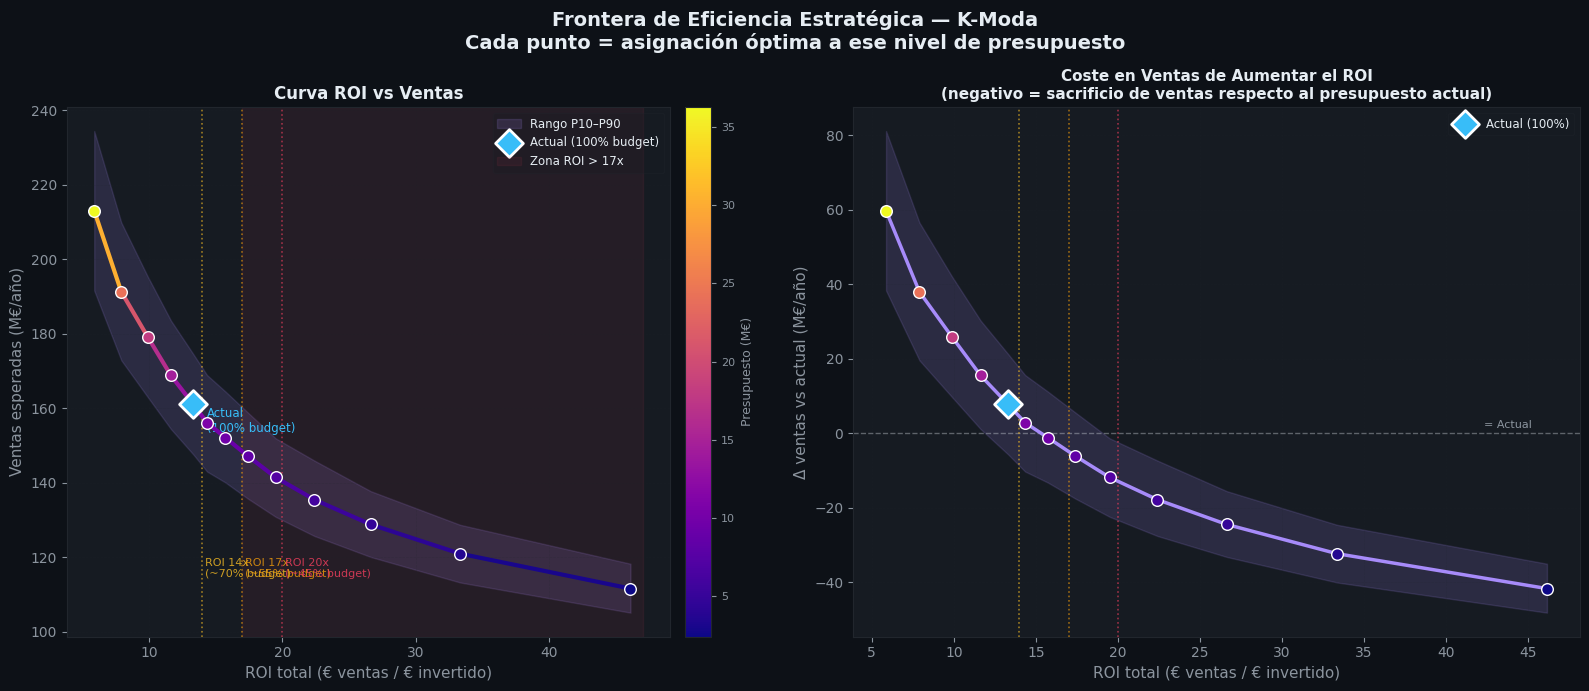

Guardado: decision_05_efficiency_frontier.png

IMPLICACIONES DE PRESUPUESTO PARA CADA OBJETIVO DE ROI
    ROI objetivo    Budget necesario   vs actual   Ventas M€
  ──────────────────────────────────────────────────────────
           12.5x      12.1 M€ (100%)         +1%      161.0 ◄
           13.0x      12.1 M€ (100%)         +1%      161.0 ◄
           14.0x      10.9 M€ (90%)         -9%      156.1 ◄
           15.0x      10.9 M€ (90%)         -9%      156.1 ◄
           17.0x       8.5 M€ (70%)        -29%      147.2 ◄
           20.0x       7.3 M€ (60%)        -39%      141.4 ◄


In [14]:
if len(frontier) < 3:
    print("Pocos puntos para trazar. Verifica que simulate_scenario esté definido.")
else:
    roi_vals   = [sc["roi_achieved"]       for sc in frontier]
    sales_vals = [sc["sales_central"]/1e6  for sc in frontier]
    p10_vals   = [sc["sales_p10"]/1e6      for sc in frontier]
    p90_vals   = [sc["sales_p90"]/1e6      for sc in frontier]
    delta_vals = [sc["delta_vs_actual"]/1e6 for sc in frontier]
    budgets    = [sc["budget_euros"]/1e6    for sc in frontier]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor=DARK_BG)
    fig.suptitle(
        "Frontera de Eficiencia Estratégica — K-Moda\n"
        "Cada punto = asignación óptima a ese nivel de presupuesto",
        fontsize=14, fontweight="bold", color=TEXT_C,
    )

    # ─── Panel izquierdo: ROI vs Ventas ──────────────────────────────────────
    ax1 = axes[0]
    ax1.set_facecolor(CARD_BG)

    # Banda de incertidumbre
    ax1.fill_between(roi_vals, p10_vals, p90_vals,
                     alpha=0.15, color="#a78bfa", label="Rango P10–P90")

    # Curva frontera (degradado de color: frío=bajo presupuesto, cálido=alto)
    _pts = np.array(list(zip(roi_vals, sales_vals)))
    from matplotlib.collections import LineCollection
    segments = [_pts[i:i+2] for i in range(len(_pts)-1)]
    lc = LineCollection(segments, cmap="plasma",
                        norm=plt.Normalize(min(budgets), max(budgets)),
                        linewidth=3, zorder=4)
    lc.set_array(np.array([(budgets[i]+budgets[i+1])/2 for i in range(len(budgets)-1)]))
    ax1.add_collection(lc)
    cb = plt.colorbar(lc, ax=ax1, pad=0.02)
    cb.set_label("Presupuesto (M€)", color=TEXT_S, fontsize=9)
    cb.ax.yaxis.set_tick_params(color=TEXT_S)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT_S, fontsize=8)

    # Scatter de puntos individuales
    scatter_c = plt.cm.plasma(
        (np.array(budgets) - min(budgets)) / (max(budgets) - min(budgets)))
    for i, sc in enumerate(frontier):
        ax1.scatter(roi_vals[i], sales_vals[i],
                    color=scatter_c[i], s=70, zorder=6, edgecolors="white", lw=1.0)

    # Punto actual (100% budget)
    idx_actual = next((i for i, sc in enumerate(frontier)
                       if abs(sc["budget_fraction"] - 1.0) < 0.05), None)
    if idx_actual is not None:
        ax1.scatter(roi_vals[idx_actual], sales_vals[idx_actual],
                    color="#38bdf8", s=200, zorder=9, marker="D",
                    edgecolors="white", lw=2, label=f"Actual (100% budget)")
        ax1.annotate("Actual\n(100% budget)",
                     (roi_vals[idx_actual], sales_vals[idx_actual]),
                     xytext=(10, -20), textcoords="offset points",
                     fontsize=8.5, color="#38bdf8",
                     arrowprops=dict(arrowstyle="->", color="#38bdf8", lw=1.0))

    # Líneas de referencia en ROI targets
    for roi_ref, label, clr in [
        (14.0, "ROI 14x\n(~70% budget)", "#fbbf24"),
        (17.0, "ROI 17x\n(~55% budget)", "#f59e0b"),
        (20.0, "ROI 20x\n(~45% budget)", "#f43f5e"),
    ]:
        if min(roi_vals) <= roi_ref <= max(roi_vals):
            # Interpolate sales at this ROI
            idx_near = np.argmin([abs(r - roi_ref) for r in roi_vals])
            ax1.axvline(roi_ref, color=clr, ls=":", lw=1.2, alpha=0.6)
            ax1.text(roi_ref + 0.2, min(sales_vals) + 3, label,
                     color=clr, fontsize=8, alpha=0.8)

    # Zona ROI > 17 sombreada
    if max(roi_vals) > 17:
        ax1.axvspan(17, max(roi_vals) * 1.02, alpha=0.07, color="#f43f5e",
                    label="Zona ROI > 17x")

    ax1.set_xlabel("ROI total (€ ventas / € invertido)", color=TEXT_S, fontsize=11)
    ax1.set_ylabel("Ventas esperadas (M€/año)", color=TEXT_S, fontsize=11)
    ax1.set_title("Curva ROI vs Ventas", color=TEXT_C, fontsize=12, fontweight="bold")
    ax1.tick_params(colors=TEXT_S)
    ax1.grid(True, alpha=0.2)
    ax1.legend(fontsize=8.5, framealpha=0.3)
    for sp in ax1.spines.values(): sp.set_edgecolor(GRID_C)

    # ─── Panel derecho: ROI vs Δ ventas vs actual ────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor(CARD_BG)

    ax2.fill_between(roi_vals,
                     [p10_vals[i] - (baseline_anual/1e6) for i in range(len(frontier))],
                     [p90_vals[i] - (baseline_anual/1e6) for i in range(len(frontier))],
                     alpha=0.15, color="#a78bfa")
    ax2.plot(roi_vals, delta_vals, color="#a78bfa", lw=2.5, zorder=4)
    for i, sc in enumerate(frontier):
        ax2.scatter(roi_vals[i], delta_vals[i],
                    color=scatter_c[i], s=70, zorder=6, edgecolors="white", lw=1.0)

    ax2.axhline(0, color=TEXT_C, lw=1.0, alpha=0.35, ls="--")
    ax2.text(max(roi_vals)*0.98, 1.5, "= Actual", color=TEXT_S, fontsize=8, ha="right")

    if idx_actual is not None:
        ax2.scatter(roi_vals[idx_actual], delta_vals[idx_actual],
                    color="#38bdf8", s=200, zorder=9, marker="D",
                    edgecolors="white", lw=2, label="Actual (100%)")

    for roi_ref, label, clr in [
        (14.0, "ROI 14x", "#fbbf24"), (17.0, "ROI 17x", "#f59e0b"),
        (20.0, "ROI 20x", "#f43f5e"),
    ]:
        if min(roi_vals) <= roi_ref <= max(roi_vals):
            ax2.axvline(roi_ref, color=clr, ls=":", lw=1.2, alpha=0.6)

    ax2.set_xlabel("ROI total (€ ventas / € invertido)", color=TEXT_S, fontsize=11)
    ax2.set_ylabel("Δ ventas vs actual (M€/año)", color=TEXT_S, fontsize=11)
    ax2.set_title("Coste en Ventas de Aumentar el ROI\n"
                  "(negativo = sacrificio de ventas respecto al presupuesto actual)",
                  color=TEXT_C, fontsize=11, fontweight="bold")
    ax2.tick_params(colors=TEXT_S)
    ax2.grid(True, alpha=0.2)
    ax2.legend(fontsize=8.5, framealpha=0.3)
    for sp in ax2.spines.values(): sp.set_edgecolor(GRID_C)

    plt.tight_layout()
    plt.savefig("decision_05_efficiency_frontier.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("Guardado: decision_05_efficiency_frontier.png")

    # ── Tabla de implicaciones para ROI targets concretos ────────────────────
    print()
    print("IMPLICACIONES DE PRESUPUESTO PARA CADA OBJETIVO DE ROI")
    print("=" * 72)
    print(f"  {'ROI objetivo':>14}  {'Budget necesario':>18}  "
          f"{'vs actual':>10}  {'Ventas M€':>10}")
    print("  " + "─" * 58)
    for roi_target_show in [12.5, 13.0, 14.0, 15.0, 17.0, 20.0]:
        # Interpolación lineal sobre la frontera
        diffs = [abs(sc["roi_achieved"] - roi_target_show) for sc in frontier]
        idx   = int(np.argmin(diffs))
        sc_near = frontier[idx]
        bgt_pct = sc_near["budget_fraction"] * 100
        bgt_eur = sc_near["budget_euros"]
        delta_bgt = (sc_near["budget_euros"] - BUDGET_TOTAL) / BUDGET_TOTAL * 100
        marker = " ◄" if abs(sc_near["roi_achieved"] - roi_target_show) < 1.5 else " ~"
        print(f"  {roi_target_show:>13.1f}x  "
              f"{bgt_eur/1e6:>8.1f} M€ ({bgt_pct:.0f}%)  "
              f"{delta_bgt:>+9.0f}%  {sc_near['sales_central']/1e6:>9.1f}{marker}")


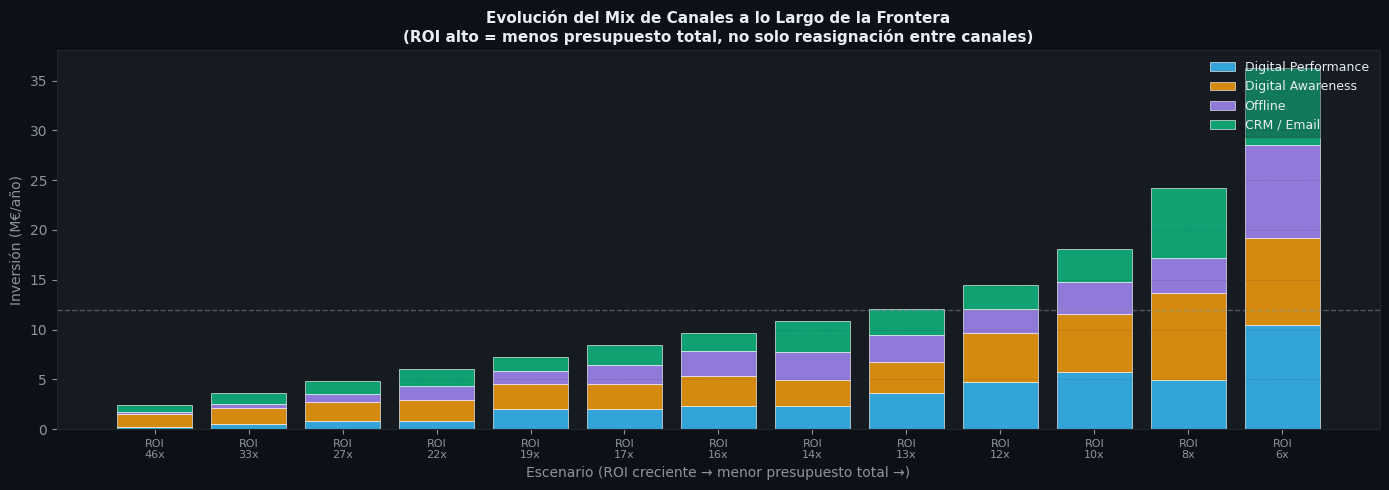

Guardado: decision_06_frontier_alloc.png


In [15]:
# ── Cómo cambia el mix de canales a lo largo de la frontera ──────────────────
if len(frontier) >= 3:
    fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK_BG)
    ax.set_facecolor(CARD_BG)

    _roi_labels = [f"ROI\n{sc['roi_achieved']:.0f}x" for sc in frontier]
    bottom = np.zeros(len(frontier))
    for g in grupo_cols:
        vals = np.array([sc["alloc"][g]/1e6 for sc in frontier])
        ax.bar(range(len(frontier)), vals, bottom=bottom,
               color=CHANNEL_COLORS[g], alpha=0.85,
               edgecolor="white", lw=0.5, label=nombres[g])
        bottom += vals

    ax.axhline(BUDGET_TOTAL/1e6, color=TEXT_S, ls="--", lw=1.0, alpha=0.5)
    ax.set_xticks(range(len(frontier)))
    ax.set_xticklabels(_roi_labels, fontsize=8)
    ax.set_xlabel("Escenario (ROI creciente → menor presupuesto total →)", color=TEXT_S)
    ax.set_ylabel("Inversión (M€/año)", color=TEXT_S)
    ax.set_title(
        "Evolución del Mix de Canales a lo Largo de la Frontera\n"
        "(ROI alto = menos presupuesto total, no solo reasignación entre canales)",
        color=TEXT_C, fontsize=11, fontweight="bold",
    )
    ax.tick_params(colors=TEXT_S)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=9, framealpha=0.3, loc="upper right")
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)

    plt.tight_layout()
    plt.savefig("decision_06_frontier_alloc.png", dpi=150,
                bbox_inches="tight", facecolor=DARK_BG)
    plt.show()
    print("Guardado: decision_06_frontier_alloc.png")


### Interpretación estratégica

La frontera de eficiencia revela la mecánica fundamental del marketing mix
bajo rendimientos decrecientes:

#### Por qué aumentar el ROI requiere reducir presupuesto

Todos los canales siguen una curva de saturación `log1p(inversión / k)`:
el retorno por euro adicional disminuye a medida que se invierte más.
**Al reducir el presupuesto total, se eliminan las inversiones con menor retorno marginal, concentrando el gasto en los tramos más eficientes de cada canal**, donde el retorno marginal es mayor.

| Zona de la frontera | ROI típico | Budget | Perfil estratégico |
|---------------------|-----------|--------|--------------------|
| **Alto volumen** | ~8–10x | > 150% actual | Crecimiento, cuota de mercado |
| **Equilibrio** | ~12–14x | 80–100% actual | Mixto, sostenible |
| **Alta eficiencia** | ~17–20x | 50–70% actual | Margen, rentabilidad |
| **Máxima eficiencia** | > 25x | < 40% actual | Solo canales más eficientes |

#### La trampa del ROI alto

Perseguir un ROI de 20x no significa "optimizar el mix" — significa **invertir
menos de la mitad del presupuesto actual**. Esto puede ser correcto si el
objetivo es maximizar margen en un año de transición, pero implica renunciar a
entre 25 y 50 M€/año en ventas.

#### Decisión ejecutiva

> **No existe un ROI óptimo único. Cada nivel de eficiencia implica un nivel
> diferente de ventas, un presupuesto diferente y un posicionamiento estratégico
> distinto. La dirección debe elegir conscientemente dónde situarse en esta curva.**

Los ejes de decisión reales son:
- **Objetivo del ejercicio:** ¿crecimiento de cuota o maximización de margen?
- **Presión del accionista:** ¿se pide ROI mínimo garantizado o ventas máximas?
- **Escalabilidad de CRM:** el canal más eficiente pero con capacidad limitada
- **Horizonte temporal:** ROI alto hoy puede comprometer brand equity mañana


---
## Conclusión metodológica

Este cuaderno separa explícitamente dos capas:

| Capa | Qué hace | Herramienta |
|------|----------|-------------|
| **Modelo** | Estima el efecto causal de la inversión en ventas | ElasticNet + Adstock (marketing_mix.ipynb) |
| **Decisión** | Evalúa trade-offs bajo incertidumbre | Este simulador |

El modelo no dicta la decisión — la **informa y estructura**.
El CEO puede elegir en función de:
- Tolerancia al riesgo
- Objetivos (crecimiento vs eficiencia)
- Confianza en el modelo
- Peso estratégico de cada canal (marca, performance, CRM)
